In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [67]:
df = pd.read_csv("Downloads/CrimesOnWomenData.csv")
df.head()

,Unnamed: 0,State,Year,Rape,K&A,DD,AoW,AoM,DV,WT
0,0,ANDHRA PRADESH,2001,871,765,420,3544,2271,5791,7
1,1,ARUNACHAL PRADESH,2001,33,55,0,78,3,11,0
2,2,ASSAM,2001,817,1070,59,850,4,1248,0
3,3,BIHAR,2001,888,518,859,562,21,1558,83
4,4,CHHATTISGARH,2001,959,171,70,1763,161,840,0


In [69]:
df = df.drop(columns=["Unnamed: 0"])
df["State"] = df["State"].str.upper()

In [71]:
df["Total_Crimes"] = df[["Rape", "K&A", "DD", "AoW", "AoM", "DV", "WT"]].sum(axis=1)

**Analysing Temporal and Geographical Trends**

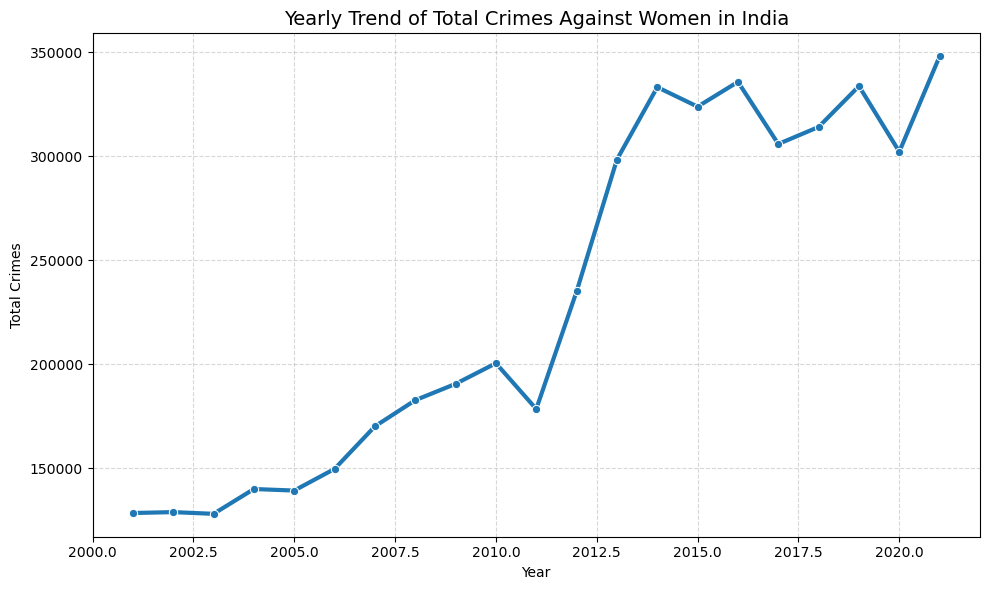

In [74]:
yearly_trend = df.groupby("Year")["Total_Crimes"].sum().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=yearly_trend, x="Year", y="Total_Crimes", marker="o", linewidth=3)
plt.title("Yearly Trend of Total Crimes Against Women in India", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Total Crimes")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

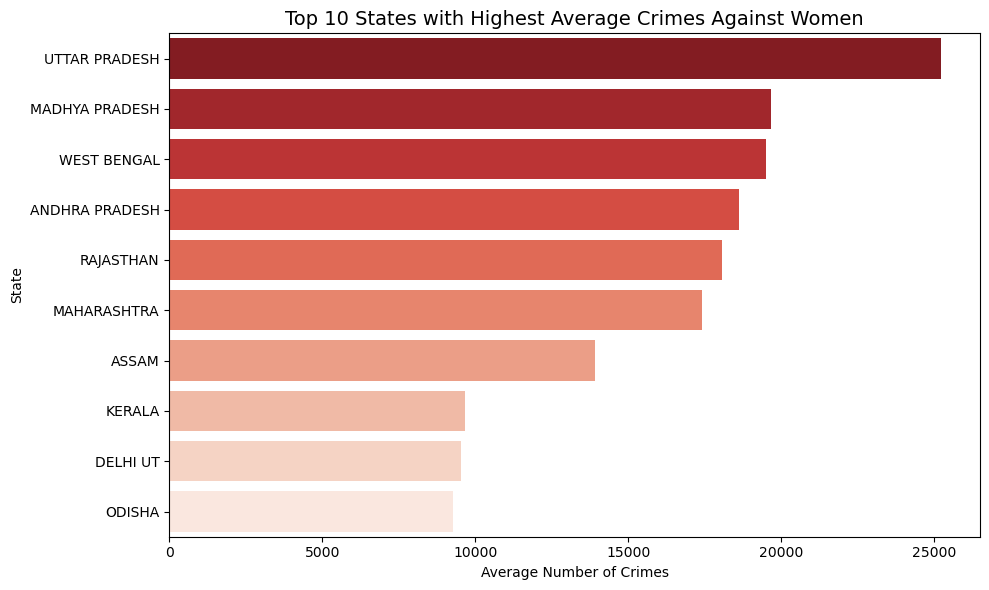

In [76]:
state_avg = df.groupby("State")["Total_Crimes"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=state_avg.values, y=state_avg.index, palette="Reds_r")
plt.title("Top 10 States with Highest Average Crimes Against Women", fontsize=14)
plt.xlabel("Average Number of Crimes")
plt.ylabel("State")
plt.tight_layout()
plt.show()

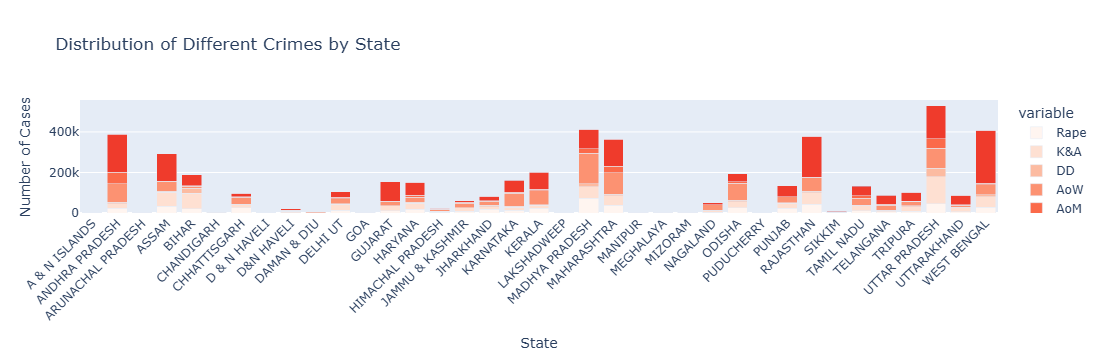

In [78]:
crime_cols = ["Rape", "K&A", "DD", "AoW", "AoM", "DV", "WT"]
state_crimes = df.groupby("State")[crime_cols].sum().reset_index()

fig = px.bar(state_crimes, 
             x="State", 
             y=crime_cols, 
             title="Distribution of Different Crimes by State",
             labels={"value": "Number of Cases", "State": "State"},
             barmode="stack",
             color_discrete_sequence=px.colors.sequential.Reds)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

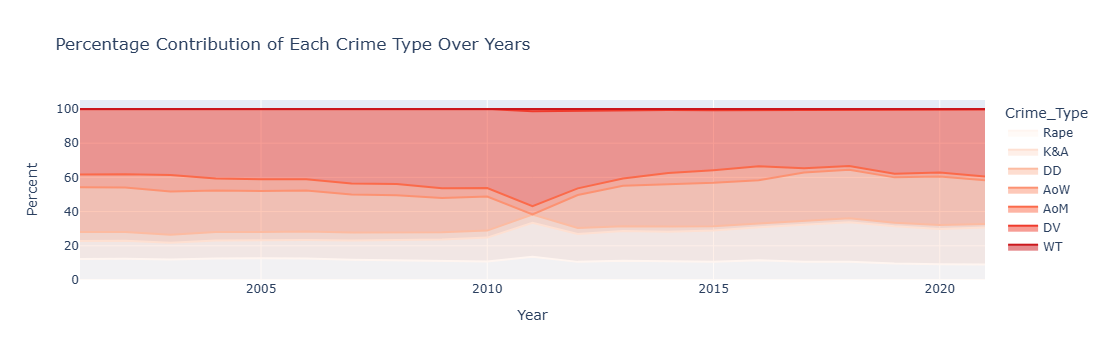

In [80]:
yearly_type = df.groupby("Year")[crime_cols].sum()
yearly_percent = (yearly_type.T / yearly_type.sum(axis=1)).T * 100
yearly_percent = yearly_percent.reset_index().melt(id_vars="Year", var_name="Crime_Type", value_name="Percent")

fig = px.area(yearly_percent, 
              x="Year", y="Percent", color="Crime_Type",
              title="Percentage Contribution of Each Crime Type Over Years",
              color_discrete_sequence=px.colors.sequential.Reds)
fig.show()

**Exploring Relationship between Crimes**

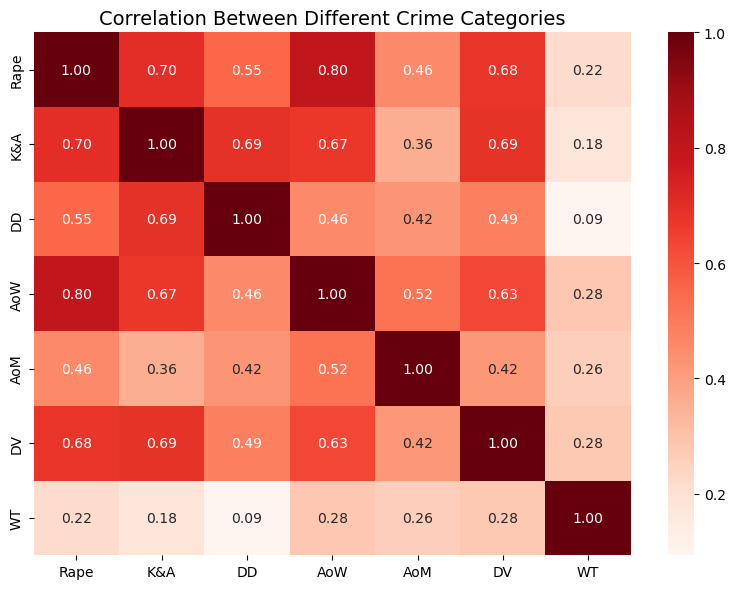

In [83]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["Rape", "K&A", "DD", "AoW", "AoM", "DV", "WT"]].corr(), 
            annot=True, cmap="Reds", fmt=".2f")
plt.title("Correlation Between Different Crime Categories", fontsize=14)
plt.tight_layout()
plt.show()

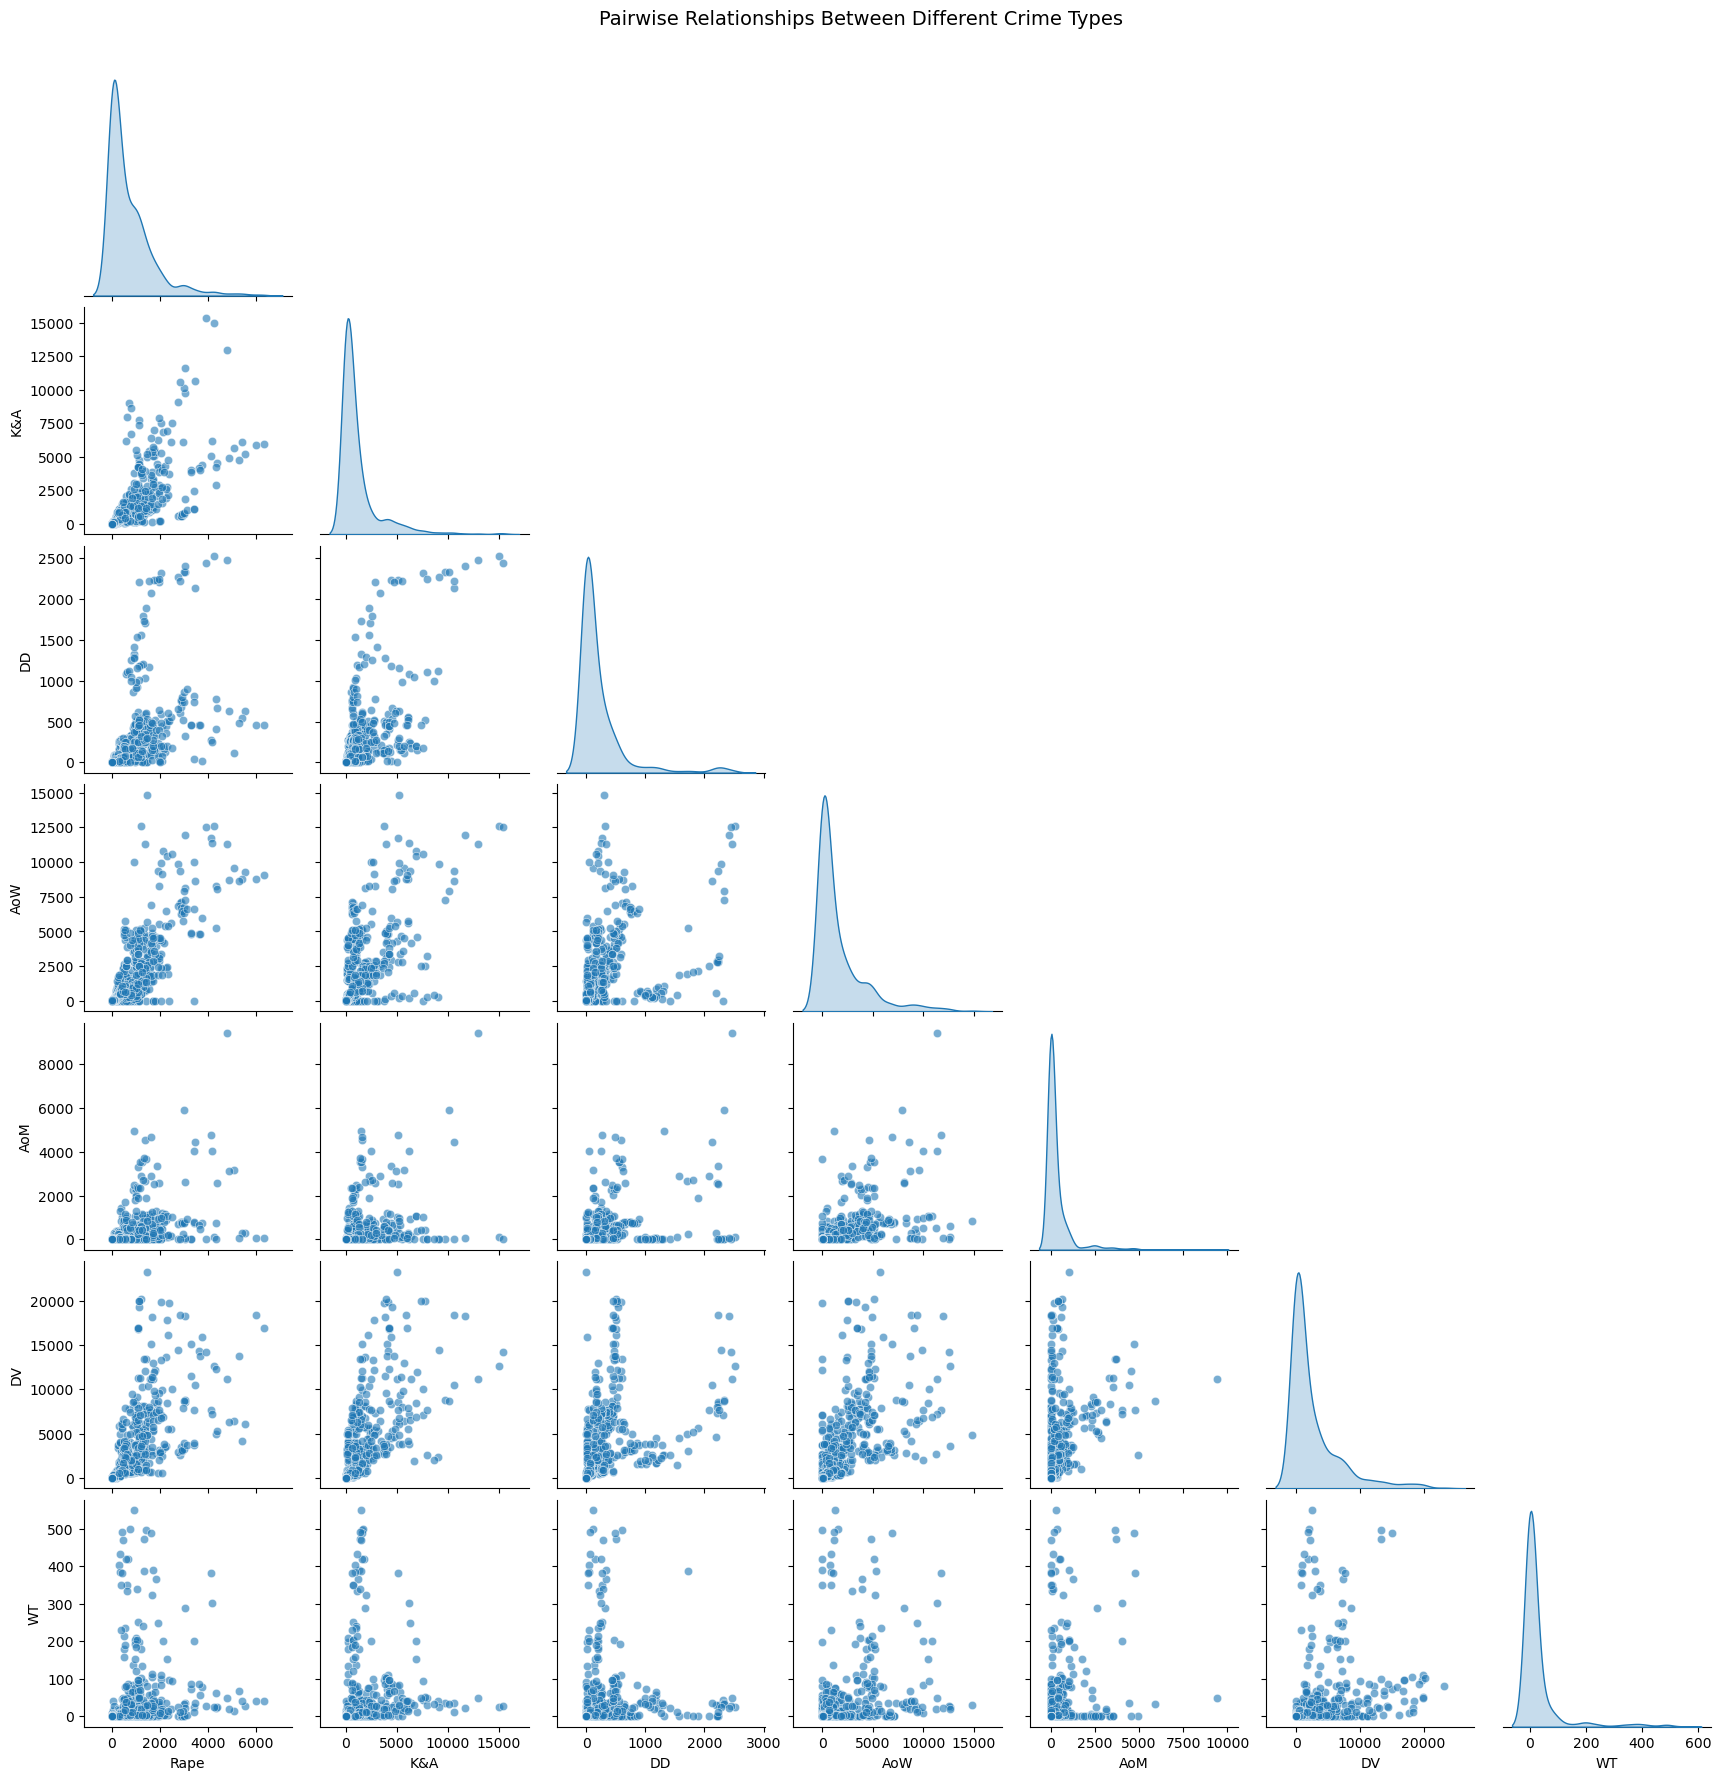

In [85]:
sns.pairplot(df[crime_cols], diag_kind="kde", corner=True, plot_kws={'alpha':0.6})
plt.suptitle("Pairwise Relationships Between Different Crime Types", y=1.02, fontsize=14)
plt.show()

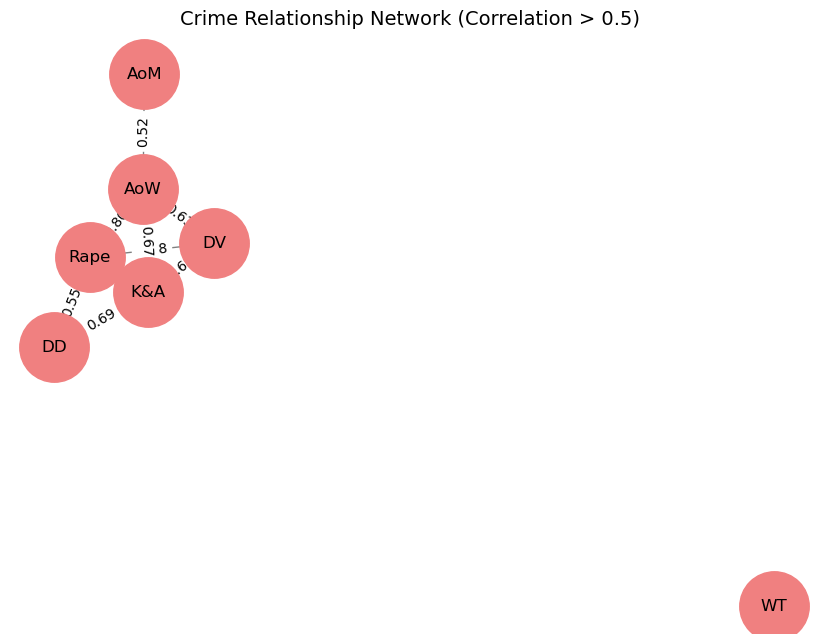

In [87]:
G = nx.Graph()
corr = df[crime_cols].corr()
for col in crime_cols:
    G.add_node(col)

for i in range(len(crime_cols)):
    for j in range(i+1, len(crime_cols)):
        weight = corr.iloc[i, j]
        if abs(weight) > 0.5:  # only strong relationships
            G.add_edge(crime_cols[i], crime_cols[j], weight=weight)

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
edges = G.edges(data=True)
nx.draw(G, pos, with_labels=True, node_color="lightcoral", node_size=2500, 
        font_size=12, edge_color="gray")
labels = { (u,v): f"{d['weight']:.2f}" for u,v,d in edges }
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Crime Relationship Network (Correlation > 0.5)", fontsize=14)
plt.tight_layout()
plt.show()

**PCA to Identify which crimes occur together**

In [90]:
X = df[crime_cols]
X_scaled = StandardScaler().fit_transform(X)

In [92]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

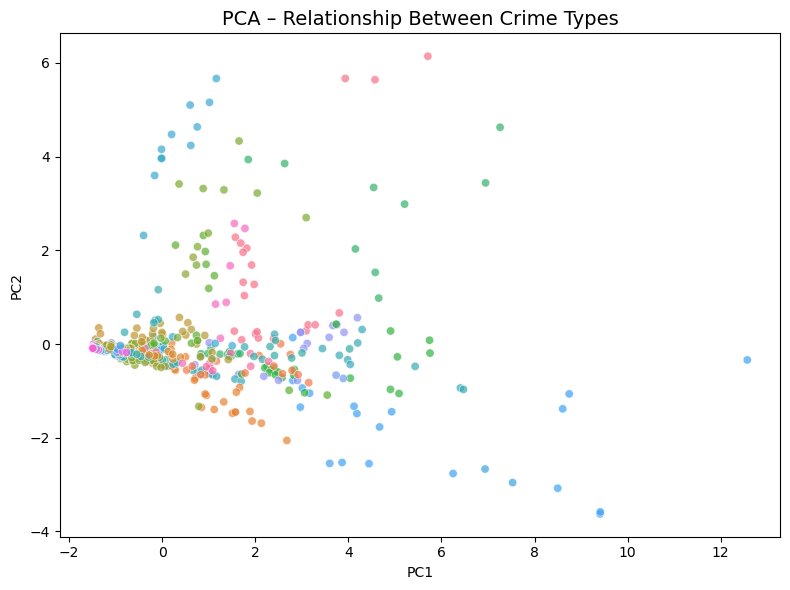

In [94]:
df_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
df_pca["State"] = df["State"]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="State", legend=False, alpha=0.7)
plt.title("PCA – Relationship Between Crime Types", fontsize=14)
plt.tight_layout()
plt.show()

In [96]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.56891642 0.14135071]
